In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rcParams
import scipy.io as spio

params = {
        "font.family" : "Arial",
        'pdf.fonttype' : 42,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'axes.linewidth': 0.5,
        'xtick.labelsize':9,
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'ytick.labelsize':9,
        'axes.spines.top':False,
        'axes.spines.right':False
         }
rcParams['figure.figsize'] = 21.7,8.27
rcParams.update(params)
def format_ax(ax,xlim,ylim,xspace,yspace):
   

    ax.set_xticks(np.arange(xlim[0],xlim[1]+ xspace,xspace))
    ax.set_yticks(np.arange(ylim[0],ylim[1]+ yspace,yspace))

    ax.set(ylim=(ylim[0], ylim[1]))
    ax.set(xlim=(xlim[0], xlim[1]))

In [3]:
### Function to convert matlab struct to python dictionary, adapted from https://stackoverflow.com/questions/7008608/scipy-io-loadmat-nested-structures-i-e-dictionaries
def loadmat(filename):
    '''
    this function should be called instead of direct spio.loadmat
    as it cures the problem of not properly recovering python dictionaries
    from mat files. It calls the function check keys to cure all entries
    which are still mat-objects
    '''
    def _check_keys(d):
        '''
        checks if entries in dictionary are mat-objects. If yes
        todict is called to change them to nested dictionaries
        '''
        for key in d:
            if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
                d[key] = _todict(d[key])
        return d

    def _todict(matobj):
        '''
        A recursive function which constructs from matobjects nested dictionaries
        '''
        d = {}
        for strg in matobj._fieldnames:
            elem = matobj.__dict__[strg]
            if isinstance(elem, spio.matlab.mio5_params.mat_struct):
                d[strg] = _todict(elem)
            elif isinstance(elem, np.ndarray):
                d[strg] = _tolist(elem)
            else:
                d[strg] = elem
        return d

    def _tolist(ndarray):
        '''
        A recursive function which constructs lists from cellarrays
        (which are loaded as numpy ndarrays), recursing into the elements
        if they contain matobjects.
        '''
        elem_list = []
        for sub_elem in ndarray:
            if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):
                elem_list.append(_todict(sub_elem))
            elif isinstance(sub_elem, np.ndarray):
                elem_list.append(_tolist(sub_elem))
            else:
                elem_list.append(sub_elem)
        return elem_list
    data = spio.loadmat(filename, struct_as_record=False, squeeze_me=True)
    return _check_keys(data)

In [4]:
### Function to align trials to event onsets, adapted from https://www.tdt.com/docs/sdk/offline-data-analysis/offline-data-python/examples/LickBouts/#time-filter-around-lick-bout-epocs
def trial_align(event_on,time,values,fps = 20,pre = 2, post = 10):
    TRANGE = [-pre*np.floor(fps), post*np.floor(fps)]

    trial_snips = []
    array_ind = []
    pre_stim = []
    post_stim = []

    for on in event_on:
        
            # If the bout cannot include pre-time seconds before event, make zero
        if on < pre:
            pass

        else: 
            # find first time index after bout onset
            array_ind.append(np.where(time > on)[0][0])
            # find index corresponding to pre and post stim durations
            pre_stim.append(array_ind[-1] + TRANGE[0])
            post_stim.append(array_ind[-1] + TRANGE[1])
            trial_snips.append(values[int(pre_stim[-1]):int(post_stim[-1])])
    
    # If some snippets are less than max length, add nans to end of array

    max1 = np.max([np.size(x) for x in trial_snips])
    for i,x in enumerate(trial_snips):
        if np.size(x) < max1:
            trial_snips[i] = np.concatenate((trial_snips[i],np.full((max1-np.size(trial_snips[i])), np.nan)))
    
    mean_trial_snips = np.mean(trial_snips, axis=0)
    peri_time = np.linspace(1, len(mean_trial_snips), len(mean_trial_snips))/fps - pre
    return trial_snips,peri_time

In [5]:
### Path to data. RENAME THIS TO YOUR PATH
base_dir = "/Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata"

In [ ]:
### Get VGAT data for Fig2C

id_date = { 
"004072" : ["20230717"],
"004075" : ["20230717","20230825"],
"004073" : ["20230808","20230811"],
"004109" : ["20230808","20230811"],
"004110" : ["20230808","20230815"],
"004111" : ["20230815"],
"004112" : ["20230811","20230815"]
}
sess =1
pre = 10
post = 20
df_list = []
labels = list(range(1,5))
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        mat_data = loadmat(matpath)["data"]
        laser_times = mat_data["response"]["laser_time"]
        pupil_snips,pupil_peri_times = trial_align(laser_times,times,areas,pre = pre, post = post)
        baselines = []
        slopes = []
        for trial in pupil_snips:
            pre_laser = np.nanmean(trial[160:200])
        for j,trial in enumerate(pupil_snips):
            baseline = np.nanmean(trial[160:200])
            trial = trial - baseline
            for i,time in enumerate(pupil_peri_times):
                new_dict = {"Time from Laser (s)" : time, "trial" : j, "value" : trial[i],"type" : "pupil", "ID" : id, "date" : date,"sess":sess}
                df_list.append(new_dict)

vgat_df = pd.DataFrame.from_dict(df_list)

In [ ]:
### Get mCherry data for Fig2C

id_date = { 
"004259" : ["20240513"],
"004260" : ["20240513"],
"004261" : ["20240513"],
"004263": ["20240513"],
"004262" : ["20240513"],
"004264" : ["20240513"],
}
sess =1
pre = 10
post = 20
df_list = []
labels = list(range(1,5))
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        mat_data = loadmat(matpath)["data"]
        laser_times = mat_data["response"]["laser_time"]

        pupil_snips,pupil_peri_times = trial_align(laser_times,times,areas,pre = pre, post = post)
        baselines = []
        slopes = []
        for trial in pupil_snips:
            pre_laser = np.nanmean(trial[160:200])
        for j,trial in enumerate(pupil_snips):
            baseline = np.nanmean(trial[160:200])
            trial = trial - baseline
            for i,time in enumerate(pupil_peri_times):
                new_dict = {"Time from Laser (s)" : time, "trial" : j, "value" : trial[i], "ID" : id, "date" : date,"sess":sess}
                df_list.append(new_dict)

mcherry_df = pd.DataFrame.from_dict(df_list)

In [ ]:
### Plot Fig2C
plt.figure(figsize = (1.6,1.6))

ax = sns.lineplot(data = vgat_df.groupby(["ID","type","Time from Laser (s)"]).mean().reset_index(), x = "Time from Laser (s)", y = "value",errorbar = "se",color = "dodgerblue",linewidth = 1)
ax = sns.lineplot(data = mcherry_df.groupby(["ID","Time from Laser (s)"]).mean().reset_index(), x = "Time from Laser (s)", y = "value",errorbar = "se",color = "grey",linewidth = 1,alpha = 0.5)

ax.axvspan(0,5,alpha = 0.2)
format_ax(ax,[-2,8],[-0.4,0.3],2,0.1)
ax.set_xlabel("Time from laser (s)")
ax.set_ylabel("Pupil size (z-scr)")

In [6]:
### Get VGAT data for Fig2D (Left)

id_date = { 
"004072" : ["20230717"],
"004075" : ["20230717","20230825"],
"004073" : ["20230808","20230811"],
"004109" : ["20230808","20230811"],
"004110" : ["20230808","20230815"],
"004111" : ["20230815"],
"004112" : ["20230811","20230815"]
}

sess =1
pre = 10
post = 10
df_list = []
delta_list = []

for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        mat_data = loadmat(matpath)["data"]
        laser_times = mat_data["response"]["laser_time"]

        pupil_snips,pupil_peri_times = trial_align(laser_times,times,areas,pre = pre, post = post)
        for j,trial in enumerate(pupil_snips):
            pre_laser = np.nanmean(trial[160:200])
            post_laser = np.nanmean(trial[280:300])

            new_dict = {"Delta" : post_laser - pre_laser,"ID" : id,'Condition':"VGAT","Date":date,"trial":j}
            delta_list.append(new_dict)

delta_df = pd.DataFrame.from_dict(delta_list)

004072 20230717


KeyboardInterrupt: 

In [ ]:
### Plot Fig2D (Left)
plt.figure(figsize = (0.5,1.2))
g = sns.barplot(data = delta_df.groupby(["ID"]).mean().reset_index(), y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "dodgerblue")
sns.stripplot(data = delta_df.groupby(["ID"]).mean().reset_index(),y = "Delta",color = "black",alpha = 0.3,s = 3,jitter = 0.2)

g.set_yticks(np.arange(-0.5,0.75,0.25))
g.set(ylim=(-0.5, 0.5))
g.set_ylabel("∆ Pupil size (z-scr)")

g.set_xlabel("ChR2")

In [ ]:
### Get mCherry data for Fig2D (Right)

id_date = { 
"004259": ["20240513"],
"004260": ["20240513"],
 "004261": ["20240513"],
 "004262": ["20240513"],
"004263": ["20240513"],
"004264": ["20240513"],

}
sess =1
pre = 10
post = 10
df_list = []
delta_list = []

for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        mat_data = loadmat(matpath)["data"]
        laser_times = mat_data["response"]["laser_time"]

        pupil_snips,pupil_peri_times = trial_align(laser_times,times,areas,pre = pre, post = post)
        for j,trial in enumerate(pupil_snips):
            pre_laser = np.nanmean(trial[160:200])
            post_laser = np.nanmean(trial[280:300])

            new_dict = {"Delta" : post_laser - pre_laser,"ID" : id,'Condition':"VGAT","Date":date,"trial":j}
            delta_list.append(new_dict)

mcherry_delta_df = pd.DataFrame.from_dict(delta_list)


In [ ]:
### Plot Fig2D (Right)

plt.figure(figsize = (0.5,1.2))
g = sns.barplot(data = mcherry_delta_df.groupby(["ID"]).mean().reset_index(), y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "black")
sns.stripplot(data = mcherry_delta_df.groupby(["ID"]).mean().reset_index(),y = "Delta",color = "black",alpha = 0.3,s = 3,jitter = 0.2)

g.set_yticks(np.arange(-0.5,0.75,0.25))
g.set(ylim=(-0.5, 0.5))
g.yaxis.label.set_visible(False)
g.axes.yaxis.set_ticklabels([])

g.set_xlabel("mCherry")

In [7]:
### Get data for Fig2E 

id_date = { 
"004072" : ["20230720"],
"004075" : ["20230720"],
"004109" : ["20230822","20230824"],
"004110" : ["20230906"],
"004111" : ["20230824"],
"004112" : ["20230822","20230824"],
}

sess =1
pre = 10
post = 10
df_list = []
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        mat_data = loadmat(matpath)["data"]
        laser_times = mat_data["response"]["laser_time"]
        laser_durs = mat_data["response"]["trial_dur"]

        pupil_snips,pupil_peri_times = trial_align(laser_times,times,areas,pre = pre, post = post)
        for j,trial in enumerate(pupil_snips):
            pre_laser = np.nanmean(trial[160:200])

            duration_frames = int((laser_durs[j]/1000) *20)
            post_laser = np.nanmean(trial[200 + (duration_frames-10):200 + duration_frames])
            
            new_dict = {"Delta" : post_laser-pre_laser,"ID" : id,'Condition':"VGAT","Date":date,"trial":j,"duration":str(int(laser_durs[j])/1000)}
            df_list.append(new_dict)

dur_df = pd.DataFrame.from_dict(df_list)


004072 20230720


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004075 20230720


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004109 20230822


...

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004112 20230822


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004112 20230824


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


In [9]:
### Get data for Fig2E (5sec duration)

id_date = { 
"004072" : ["20230717"],
"004075" : ["20230717","20230825"],
"004073" : ["20230808","20230811"],
"004109" : ["20230808","20230811"],
"004110" : ["20230808","20230815"],
"004111" : ["20230815"],
"004112" : ["20230811","20230815"]
}

###20hz frequency
sess =1
pre = 10
post = 10   
df_list = []
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        mat_data = loadmat(matpath)["data"]
        laser_times = mat_data["response"]["laser_time"]


        pupil_snips,pupil_peri_times = trial_align(laser_times,times,areas,pre = pre, post = post)
        for j,trial in enumerate(pupil_snips):
            pre_laser = np.nanmean(trial[160:200])
            duration_frames = int((laser_durs[j]/1000) *20)
            post_laser = np.nanmean(trial[200 + (duration_frames-10):200 + duration_frames])
            
            new_dict = {"Delta" : post_laser-pre_laser,"ID" : id,'Condition':"VGAT","Date":date,"trial":j,"duration":"5"}
            df_list.append(new_dict)

dur1_df = pd.DataFrame.from_dict(df_list)
dur_df = pd.concat([dur_df,dur1_df])
dur_df = dur_df.query("ID != '004073'")

004072 20230717


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004075 20230717


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004075 20230825


...

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004112 20230811


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004112 20230815


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/1856687060.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = dur_df.groupby(["ID",'duration']).mean().reset_index(), x = "duration", y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "black",order = ["0.5","1.0","2.0","5"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/1856687060.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = dur_df.groupby(["ID",'duration']).mean().reset_index(), x = "duration", y = "Delta",units = "ID",estimator = None,color = "black",alpha = 

Text(0.5, 0, 'Laser Duration (s)')

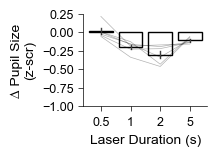

In [10]:
### Plot Fig2E
plt.figure(figsize = (1.6,1.2))
g = sns.barplot(data = dur_df.groupby(["ID",'duration']).mean().reset_index(), x = "duration", y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "black",order = ["0.5","1.0","2.0","5"])
sns.lineplot(data = dur_df.groupby(["ID",'duration']).mean().reset_index(), x = "duration", y = "Delta",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)

g.set_xticks(list(g.get_xticks()),labels = ["0.5","1","2","5"])

g.set_yticks(np.arange(-1,0.5,0.25))
g.set(ylim=(-1, 0.25))
g.set_ylabel("∆ Pupil Size\n(z-scr)")
g.set_xlabel("Laser Duration (s)")

In [12]:
### Get data for Fig2F

id_date = { 
"004072" : ["20230721","20230718"],
"004075" : ["20230721","20230718"],
"004073" : ["20230817"],
"004109" : ["20230817","20230821"],
"004110" : ["20230817","20230821"],
"004111" : ["20230817","20230821"],
"004112" : ["20230817","20230821"]
}

sess =1
pre = 10
post = 10
df_list = []
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        mat_data = loadmat(matpath)["data"]
        laser_times = mat_data["response"]["laser_time"]
        laser_itis = mat_data["response"]["trial_iti"]
        laser_widths = mat_data["response"]["trial_pulse_width"]
        laser_freqs = [np.round((width/(iti + width)) * 100) for iti,width in zip(laser_itis,laser_widths)]

        pupil_snips,pupil_peri_times = trial_align(laser_times,times,areas,pre = pre, post = post)
        for j,trial in enumerate(pupil_snips):
            pre_laser = np.nanmean(trial[160:200])
            post_laser = np.nanmean(trial[280:300])
            
            new_dict = {"Delta" : post_laser-pre_laser,"ID" : id,'Condition':"VGAT","Date":date,"trial":j,"frequency":str(int(laser_freqs[j]))}
            df_list.append(new_dict)

freq_df = pd.DataFrame.from_dict(df_list)


004072 20230721


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004072 20230718


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004075 20230721


...

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004112 20230817


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004112 20230821


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


In [13]:
### Get data for Fig2F (20hz frequency)
id_date = { 
"004072" : ["20230717"],
"004075" : ["20230717","20230825"],
"004073" : ["20230808","20230811"],
"004109" : ["20230808","20230811"],
"004110" : ["20230808","20230815"],
"004111" : ["20230815"],
"004112" : ["20230811","20230815"]
}

sess =1
pre = 10
post = 10   
df_list = []
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        mat_data = loadmat(matpath)["data"]
        laser_times = mat_data["response"]["laser_time"]


        pupil_snips,pupil_peri_times = trial_align(laser_times,times,areas,pre = pre, post = post)
        for j,trial in enumerate(pupil_snips):
            pre_laser = np.nanmean(trial[160:200])
            post_laser = np.nanmean(trial[280:300])
            
            new_dict = {"Delta" : post_laser-pre_laser,"ID" : id,'Condition':"VGAT","Date":date,"trial":j,"frequency":"20"}
            df_list.append(new_dict)

freq1_df = pd.DataFrame.from_dict(df_list)
freq_df = pd.concat([freq_df,freq1_df])

004072 20230717


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004075 20230717


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004075 20230825


...

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004112 20230811


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


004112 20230815


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/3130832239.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = freq_df.groupby(["ID",'frequency']).mean().reset_index(), x = "frequency", y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "black",order = ["5","10","20","30"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_12618/3130832239.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.lineplot(data = freq_df.groupby(["ID",'frequency']).mean().reset_index(), x = "frequency", y = "Delta",units = "ID",estimator = None,color = "black",alpha

Text(0.5, 0, 'Laser Freq. (Hz)')

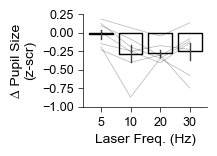

In [ ]:
### Plot Fig2F
plt.figure(figsize = (1.6,1.2))
g = sns.barplot(data = freq_df.groupby(["ID",'frequency']).mean().reset_index(), x = "frequency", y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "black",order = ["5","10","20","30"])
sns.lineplot(data = freq_df.groupby(["ID",'frequency']).mean().reset_index(), x = "frequency", y = "Delta",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
for line in g.get_lines()[4:]:
    y1,y2,y3,y4 = line.get_ydata()
    line.set_ydata([y4,y1,y2,y3])
    
g.set_yticks(np.arange(-1,0.5,0.25))
g.set(ylim=(-1, 0.25))
g.set_ylabel("∆ Pupil Size\n(z-scr)")
g.set_xlabel("Laser Freq. (Hz)")

In [ ]:
### Get VGAT data for Fig2G

id_date = { 
"004072" : ["20230717"],
"004075" : ["20230717","20230825"],
"004073" : ["20230808","20230811"],
"004109" : ["20230808","20230811"],
"004110" : ["20230808","20230815"],
"004111" : ["20230815"],
"004112" : ["20230811","20230815"]
}
sess =1
pre = 10
post = 20
df_list = []
labels = list(range(1,5))
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        face_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_FaceProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"

        pupil_df = pd.read_csv(pupil_path)
        face_df = pd.read_csv(face_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        face = face_df['Facial Movement'].to_numpy()

        mat_data = loadmat(matpath)["data"]
        laser_times = mat_data["response"]["laser_time"]

        face_snips,face_peri_times = trial_align(laser_times,times,face,pre = pre, post = post)
        for j,trial in enumerate(face_snips):
            baseline = np.nanmean(trial[160:200])
            trial = trial - baseline
            for i,time in enumerate(face_peri_times):
                new_dict = {"Time from Laser (s)" : time, "trial" : j, "value" : trial[i],"type" : "face", "ID" : id, "date" : date,"sess":sess}
                df_list.append(new_dict)

vgat_face_df = pd.DataFrame.from_dict(df_list)

In [ ]:
### Get mCherry data for Fig2G

id_date = { 
"004259": ["20240513"],
"004260": ["20240513"],
"004261": ["20240513"],
"004262": ["20240513"],
"004263": ["20240513"],
"004264": ["20240513"],
}
sess =1
pre = 10
post = 20
df_list = []
labels = list(range(1,5))
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        face_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_FaceProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"

        pupil_df = pd.read_csv(pupil_path)
        face_df = pd.read_csv(face_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        face = face_df['Facial Movement'].to_numpy()

        mat_data = loadmat(matpath)["data"]
        laser_times = mat_data["response"]["laser_time"]

     
        face_snips,face_peri_times = trial_align(laser_times,times,face,pre = pre, post = post)
        for j,trial in enumerate(face_snips):
            baseline = np.nanmean(trial[160:200])
            trial = trial - baseline
            for i,time in enumerate(face_peri_times):
                new_dict = {"Time from Laser (s)" : time, "trial" : j, "value" : trial[i],"type" : "face", "ID" : id, "date" : date,"sess":sess}
                df_list.append(new_dict)

mcherry_face_df = pd.DataFrame.from_dict(df_list)

In [ ]:
### Plot Fig2G
plt.figure(figsize = (1.6,1.6))

ax = sns.lineplot(data = vgat_face_df.groupby(["ID","type","Time from Laser (s)"]).mean().reset_index().query("type =='face'"), x = "Time from Laser (s)", y = "value",errorbar = "se",color = "dodgerblue",linewidth = 1)
ax = sns.lineplot(data = mcherry_face_df.groupby(["ID","Time from Laser (s)","type"]).mean().reset_index().query("type =='face'"), x = "Time from Laser (s)", y = "value",errorbar = "se",color = "grey",linewidth = 1,alpha = 0.5)

ax.axvspan(0,5,alpha = 0.2)
format_ax(ax,[-2,8],[-0.2,0.3],2,0.1)
ax.set_xlabel("Time from laser (s)")
ax.set_ylabel("Facial movement (z-scr)")

In [ ]:
### Get VGAT data for  Fig2H (Left)
id_date = { 
"004072" : ["20230717"],
"004075" : ["20230717","20230825"],
"004073" : ["20230808","20230811"],
"004109" : ["20230808","20230811"],
"004110" : ["20230808","20230815"],
"004111" : ["20230815"],
"004112" : ["20230811","20230815"]
}
sess =1
pre = 10
post = 10
df_list = []
delta_list = []

for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        mat_data = loadmat(matpath)["data"]
        laser_times = mat_data["response"]["laser_time"]
        face_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_FaceProcessed.csv"
        face_df = pd.read_csv(face_path)
        face = face_df['Facial Movement'].to_numpy()
        face_snips,face_peri_times = trial_align(laser_times,times,face,pre = pre, post = post)
        for j,trial in enumerate(face_snips):
            pre_laser = np.nanmean(trial[160:200])
            post_laser = np.nanmean(trial[280:300])

            new_dict = {"Delta" : post_laser - pre_laser,"ID" : id,'Condition':"VGAT","Date":date,"trial":j}
            delta_list.append(new_dict)

delta_df = pd.DataFrame.from_dict(delta_list)


In [ ]:
### Get mCherry data for  Fig2H (Right)

id_date = { 
"004259": ["20240513"],
"004260": ["20240513"],
"004261": ["20240513"],
"004262": ["20240513"],
"004263": ["20240513"],
"004264": ["20240513"],
}
sess =1
pre = 10
post = 10
df_list = []
delta_list = []

for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()
        areas = pupil_df['Pupil Area'].to_numpy()
        mat_data = loadmat(matpath)["data"]
        laser_times = mat_data["response"]["laser_time"]
        face_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_FaceProcessed.csv"
        face_df = pd.read_csv(face_path)
        face = face_df['Facial Movement'].to_numpy()


        face_snips,face_peri_times = trial_align(laser_times,times,face,pre = pre, post = post)
        for j,trial in enumerate(face_snips):
            pre_laser = np.nanmean(trial[160:200])
            post_laser = np.nanmean(trial[280:300])

            new_dict = {"Delta" : post_laser - pre_laser,"ID" : id,'Condition':"VGAT","Date":date,"trial":j}
            delta_list.append(new_dict)

mcherry_delta_df = pd.DataFrame.from_dict(delta_list)


In [ ]:
### Plot Fig2H (Left)

plt.figure(figsize = (0.5,1.2))
g = sns.barplot(data = delta_df.groupby(["ID"]).mean().reset_index(), y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "dodgerblue")
sns.stripplot(data = delta_df.groupby(["ID"]).mean().reset_index(),y = "Delta",color = "black",alpha = 0.3,s = 3,jitter = 0.2)

g.set_yticks(np.arange(-0.2,0.3,0.1))
g.set(ylim=(-0.2, 0.2))
g.set_xlabel("ChR2")
g.set_ylabel("∆ Facial movement (z-scr)")

In [ ]:
### Plot Fig2H (Right)

plt.figure(figsize = (0.5,1.2))
g = sns.barplot(data = mcherry_delta_df.groupby(["ID"]).mean().reset_index(), y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "black")
sns.stripplot(data = mcherry_delta_df.groupby(["ID"]).mean().reset_index(),y = "Delta",color = "black",alpha = 0.3,s = 3,jitter = 0.2)

g.set_yticks(np.arange(-0.2,0.3,0.1))
g.set(ylim=(-0.2, 0.2))
g.yaxis.label.set_visible(False)
g.axes.yaxis.set_ticklabels([])

g.set_xlabel("mCherry")